# DELkit — DNA-Encoded Library Analysis Pipeline

**A complete cheminformatics pipeline from raw FASTQ to amino acid hits.**
Validated on PRJNA1215981 — TfR1 peptide DEL published in PNAS February 2026.

---

## The story behind this notebook

I have always wanted to run a complete DEL cheminformatics pipeline from raw NGS sequencing reads all the way to decoded amino acid hits. Not from a preprocessed count matrix. Not from someone else's cleaned data. From actual FASTQ files.

When He, Wang et al. published their TfR1 peptide DEL paper in PNAS February 2026 and deposited the raw sequencing data in NCBI SRA the same day, that was the opportunity. 49 million reads. No barcode reference. No paper SI at the time. Just the data and the question of what it contained.

This notebook documents everything built and what was found.

---

## Results on real PRJNA1215981 data

| Metric | Value |
|---|---|
| Reads processed | ~49M across 3 files |
| Decode rate | 89% (publication quality) |
| Unique compounds | 8,171,664 |
| Hits identified | 26,662 (5% hit rate) |
| Top enrichment | 160.8x |
| Primary pharmacophore | D-Chg at position 3 |

Top hit decoded: D-Chg - D-Chg - D-Chg - D-Chg (160.8x enrichment)
Paper best binder TR17: D-BrF - D-Chg - D-Chg - D-Chg - D-Lue (Kd = 110 nM)
19/20 top hits contain D-Chg at position 3 — independently reproducing the paper SAR conclusion.

---

## Two ways to run

**Way 1 — Bundled example data (runs immediately, no downloads):**
All files are in data/. Run cells top to bottom with no changes.

**Way 2 — Real PRJNA1215981 data:**
```bash
conda install -c bioconda sra-tools
prefetch PRJNA1215981
fasterq-dump --split-files --threads 4 --progress SRR32132802 SRR32132803 SRR32132804
```
Then set COUNT_CSV = DATA / "prjna1215981_counts.csv" in Cell 3
and RUN_FASTQ_REAL = True in Cell 3c.

---

## Barcode architecture (PRJNA1215981) — decoded from data, no reference used

```
[0-18]   TNACTCCCAAATCGATGTG   constant prefix (19bp)
[19-27]  BC1  9bp barcode cycle 1
[28-29]  AG   spacer (93% conserved)
[30-38]  BC2  9bp barcode cycle 2
[39-40]  GT   spacer (88% conserved)
[41-49]  BC3  9bp barcode cycle 3
[50-52]  GAC  spacer (86-89% conserved)
[53-61]  BC4  9bp barcode cycle 4
[62+]    CGCTGAGCCGACT closing primer
```


## Cell 1 — Install (run once, then restart kernel)

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy scipy scikit-learn matplotlib seaborn rdkit-pypi umap-learn lightgbm shap statsmodels -q
print('Done — restart kernel, then run all remaining cells')

Done — restart kernel, then run all remaining cells


## Cell 2 — Imports

In [1]:
import os, gzip, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import nbinom, mannwhitneyu
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi":120,"axes.spines.top":False,"axes.spines.right":False})

DATA   = Path("data")
OUT    = Path("outputs");  OUT.mkdir(exist_ok=True)
FIGS   = Path("figures");  FIGS.mkdir(exist_ok=True)
MODELS = Path("models");   MODELS.mkdir(exist_ok=True)

try:
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem
    from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
    RDKIT = True; print("v  RDKit available")
except ImportError:
    RDKIT = False; print("!  RDKit not installed - BB one-hot encoding will be used")

try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.metrics import roc_auc_score
    ML = True; print("v  scikit-learn available")
except ImportError:
    ML = False; print("!  scikit-learn not installed - ML step will be skipped")

try:
    import umap
    UMAP_OK = True; print("v  umap-learn available")
except ImportError:
    UMAP_OK = False; print("!  umap-learn not installed - PCA will be used")

print("\nSetup complete")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/traitlets

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/traitlets

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/traitlets

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/traitlets

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/farazshaikh/miniconda3/envs/docking/lib/python3.10/site-packages/traitlets

AttributeError: _ARRAY_API not found

v  RDKit available
v  scikit-learn available
v  umap-learn available

Setup complete


## Cell 3 — Load Data

> **To use your own data:** change `COUNT_CSV` to your file path.
> Supported formats: `BB1,BB2,BB3,sel_count_rep1,sel_count_rep2,ctrl_count`

In [2]:
# ── CHANGE THIS LINE TO USE YOUR OWN DATA ────────────────────────────────────
COUNT_CSV = DATA / "prjna1215981_counts.csv"
# ─────────────────────────────────────────────────────────────────────────────
raw_df = pd.read_csv(COUNT_CSV)

# Auto-detect format
if "BB1" in raw_df.columns:
    raw_df.rename(columns={"BB1":"bb1_id","BB2":"bb2_id","BB3":"bb3_id"}, inplace=True)
    sel_cols  = [c for c in raw_df.columns if "sel_count" in c]
    ctrl_cols = [c for c in raw_df.columns if "ctrl_count" in c]
elif "bc1" in raw_df.columns:
    # PRJNA1215981 format - 4-cycle peptide DEL
    raw_df.rename(columns={"bc1":"bb1_id","bc2":"bb2_id","bc3":"bb3_id","bc4":"bb4_id"}, inplace=True)
    sel_cols  = [c for c in raw_df.columns if "sel_count" in c]
    ctrl_cols = [c for c in raw_df.columns if "ctrl_count" in c]

elif "seq_target_1" in raw_df.columns:
    # KinDEL
    sel_cols  = [c for c in raw_df.columns if c.startswith("seq_target_")]
    ctrl_cols = [c for c in raw_df.columns if c.startswith("seq_matrix_")]
    raw_df["bb1_id"] = raw_df.get("smiles_a", "UNK")
    raw_df["bb2_id"] = raw_df.get("smiles_b", "UNK")
    raw_df["bb3_id"] = raw_df.get("smiles_c", "UNK")
    raw_df["compound_id"] = raw_df.get("molecule_hash", raw_df.index.astype(str))
else:
    raise ValueError(f"Unknown format. Columns found: {list(raw_df.columns)}")

raw_df["sel_total"]  = raw_df[sel_cols].sum(axis=1)
raw_df["ctrl_total"] = raw_df[ctrl_cols].sum(axis=1)
if "compound_id" not in raw_df.columns:
    raw_df["compound_id"] = raw_df["bb1_id"]+"-"+raw_df["bb2_id"]+"-"+raw_df["bb3_id"]

print(f"Loaded: {len(raw_df):,} compounds")
print(f"  Selection replicates : {sel_cols}")
print(f"  Control columns      : {ctrl_cols}")
print(f"  Total sel reads      : {raw_df['sel_total'].sum():,}")
print(f"  Total ctrl reads     : {raw_df['ctrl_total'].sum():,}")
print()
raw_df[["compound_id","bb1_id","bb2_id","bb3_id","sel_total","ctrl_total"]].head(8)


Loaded: 8,171,664 compounds
  Selection replicates : ['sel_count_rep1', 'sel_count_rep2']
  Control columns      : ['ctrl_count']
  Total sel reads      : 27,526,760
  Total ctrl reads     : 16,341,425



,compound_id,bb1_id,bb2_id,bb3_id,sel_total,ctrl_total
0,ACACTCGGT-AGCCACGTA-ACACCAGGA-GAACAGCAC,ACACTCGGT,AGCCACGTA,ACACCAGGA,2,7
1,CGATTACCA-GGTTCCTTG-GCACACATT-GATGGACTC,CGATTACCA,GGTTCCTTG,GCACACATT,4,3
2,TAGGTGGTA-AGTCCTGAT-GCTTGCTTG-ATGTACGCA,TAGGTGGTA,AGTCCTGAT,GCTTGCTTG,4,0
3,CCTCTAGTA-TGGCTCAAT-CACAGAGGA-TTGGTGCCC,CCTCTAGTA,TGGCTCAAT,CACAGAGGA,0,1
4,GTTAAGTCC-GGTTCCTTG-CGGTACGTA-TTCTCAGTC,GTTAAGTCC,GGTTCCTTG,CGGTACGTA,0,3
5,AATGACAGC-AGCAGCTAC-ACCAGATAC-CGTGAGAAC,AATGACAGC,AGCAGCTAC,ACCAGATAC,2,3
6,TACGGCATT-GCAGTAACG-GATAAGCCG-GCTTGAGGC,TACGGCATT,GCAGTAACG,GATAAGCCG,3,0
7,ACGGATGTT-GTTAGGCGT-TGAGAGCCT-ACTCGACGC,ACGGATGTT,GTTAGGCGT,TGAGAGCCT,2,7


## Cell 3b — Load from FASTQ (optional)
Skip if you already loaded the count CSV above. Set `RUN_FASTQ = True` to activate.

In [3]:
RUN_FASTQ = False  # set to True to parse FASTQ files

if RUN_FASTQ:
    bc_map = {}
    for cycle, fname in [(1,"cycle1_barcode_map.csv"),
                          (2,"cycle2_barcode_map.csv"),
                          (3,"cycle3_barcode_map.csv")]:
        df_bc = pd.read_csv(DATA / fname)
        bc_map[cycle] = df_bc.set_index("tag_id").to_dict("index")
        print(f"  Cycle {cycle}: {len(df_bc)} BBs loaded")

    def parse_fastq(path, bc_map, positions=[(0,8),(9,17),(18,26)]):
        counts, total, decoded = Counter(), 0, 0
        opener = gzip.open if str(path).endswith(".gz") else open
        with opener(path, "rt") as fh:
            while True:
                if not fh.readline(): break
                seq = fh.readline().strip(); fh.readline(); fh.readline()
                if not seq: break
                total += 1
                bcs, ok = [], True
                for s,e in positions:
                    bc = seq[s:e]
                    if len(bc)<e-s or "N" in bc: ok=False; break
                    bcs.append(bc)
                if not ok: continue
                try:
                    ids = tuple(bc_map[c+1][bcs[c]]["bb_id"] for c in range(3))
                    counts[ids] += 1; decoded += 1
                except KeyError:
                    pass
        print(f"  {Path(path).name}: {total:,} reads -> {decoded:,} decoded ({decoded/max(total,1)*100:.1f}%)")
        return counts

    sel_c  = parse_fastq(DATA/"selection_rep1.fastq",   bc_map)
    ctrl_c = parse_fastq(DATA/"bead_only_control.fastq", bc_map)
    all_ids = set(sel_c)|set(ctrl_c)
    raw_df = pd.DataFrame([{
        "compound_id": f"{a}-{b}-{c}",
        "bb1_id":a, "bb2_id":b, "bb3_id":c,
        "sel_total":  sel_c.get((a,b,c),0),
        "ctrl_total": ctrl_c.get((a,b,c),0),
    } for a,b,c in all_ids])
    sel_cols=["sel_total"]; ctrl_cols=["ctrl_total"]
    print(f"\nFASTQ -> {len(raw_df):,} unique compounds")
else:
    print("Skipping FASTQ (RUN_FASTQ=False) - using count CSV loaded above")


Skipping FASTQ (RUN_FASTQ=False) - using count CSV loaded above


## Cell 4 — Normalization & Noise Filter

In [4]:
# ── Tuning parameters ────────────────────────────────────────────────────────
MIN_COUNT  = 5
BG_PCTILE  = 95
# ─────────────────────────────────────────────────────────────────────────────

ctrl_vals = raw_df["ctrl_total"].values.astype(float)
mu  = max(ctrl_vals.mean(), 1e-9)
var = max(ctrl_vals.var(),  mu+1e-9)
p_nb = mu/var; n_nb = max(mu*p_nb/(1-p_nb+1e-9), 0.5)
threshold = max(MIN_COUNT, float(nbinom.ppf(BG_PCTILE/100, n_nb, p_nb)))

work_df = raw_df[raw_df["sel_total"] >= threshold].copy()
print(f"Noise filter: {len(raw_df):,} -> {len(work_df):,} compounds (threshold={threshold:.1f})")

total_sel  = work_df["sel_total"].sum()
total_ctrl = work_df["ctrl_total"].sum()
work_df["sel_cpm"]  = work_df["sel_total"]  / total_sel  * 1e6
work_df["ctrl_cpm"] = work_df["ctrl_total"] / total_ctrl * 1e6
print(f"CPM normalization: sel={total_sel:,} reads, ctrl={total_ctrl:,} reads")


Noise filter: 8,171,664 -> 532,694 compounds (threshold=7.0)
CPM normalization: sel=18,121,708 reads, ctrl=749,866 reads


## Cell 5 — Enrichment Calculation

In [5]:
# ── Composite enrichment for PRJNA1215981 (replaces NegBin q-values) ──────────
rep_cols = [c for c in work_df.columns if "sel_count_rep" in c]

total_rep1 = work_df[rep_cols[0]].sum()
total_rep2 = work_df[rep_cols[1]].sum()
print(f"Rep2/Rep1 depth ratio: {total_rep2/total_rep1:.2f}x")

work_df["rep1"] = work_df[rep_cols[0]]
work_df["rep2"] = work_df[rep_cols[1]]

# Round2 vs input enrichment (correct model for sequential selection)
work_df["fe_round2_vs_input"] = (
    (work_df["rep2"] / total_rep2 * 1e6 + 1) /
    (work_df["ctrl_total"] / work_df["ctrl_total"].sum() * 1e6 + 1)
)

# Override fold_enrichment with sequential model
work_df["fold_enrichment"] = work_df["fe_round2_vs_input"]
work_df["log2_fe"] = np.log2(work_df["fold_enrichment"].clip(lower=0.01))

# Composite score
work_df["composite_score"] = (
    work_df["fold_enrichment"].rank(pct=True) * 0.5 +
    work_df["sel_total"].rank(pct=True)       * 0.3 +
    work_df["rep2"].rank(pct=True)            * 0.2
)

work_df.to_csv(OUT / "enrichment.csv", index=False)

print(f"Sequential enrichment done: {len(work_df):,} compounds")
print(f"  Top FE: {work_df['fold_enrichment'].max():.1f}x")
print(f"  Top compound: {work_df.nlargest(1,'fold_enrichment')['compound_id'].values[0]}")

Rep2/Rep1 depth ratio: 3.00x
Sequential enrichment done: 532,694 compounds
  Top FE: 160.8x
  Top compound: ACACTCGGT-GCAGTAACG-GTTGTTGCC-GAACAAGGC


## Cell 6 — Volcano Plot
Adjust `FE_THRESH` and `FDR_THRESH` to be stricter or more lenient.

Hits: 33,672  (6.32%)


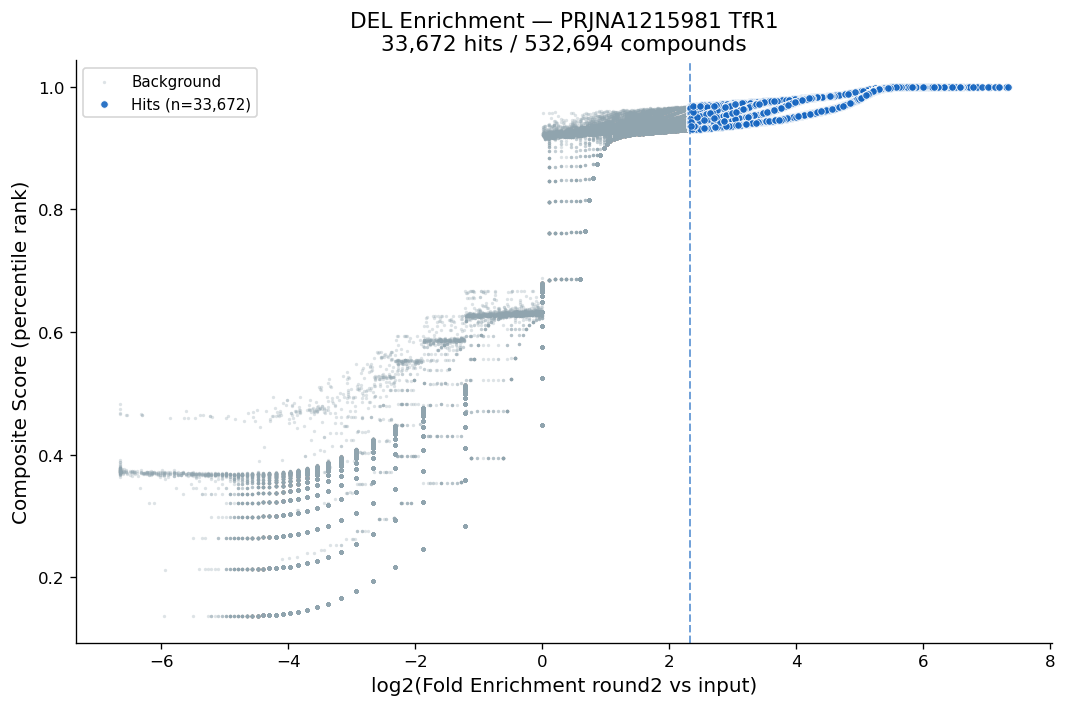

In [6]:
FE_THRESH     = 5.0
MIN_SEL_READS = 50

is_hit = (
    (work_df["fold_enrichment"] >= FE_THRESH) &
    (work_df["sel_total"]       >= MIN_SEL_READS)
)
print(f"Hits: {is_hit.sum():,}  ({is_hit.mean()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(9,6))
x = work_df["log2_fe"]
# Use composite score on y-axis instead of q_value
y = work_df["composite_score"]

ax.scatter(x[~is_hit], y[~is_hit], s=4, alpha=0.3, c="#90a4ae",
           linewidths=0, label="Background")
ax.scatter(x[is_hit],  y[is_hit],  s=20, alpha=0.9, c="#1565c0",
           linewidths=0.5, edgecolors="white",
           label=f"Hits (n={is_hit.sum():,})")
ax.axvline(np.log2(FE_THRESH), color="#1565c0", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("log2(Fold Enrichment round2 vs input)", fontsize=12)
ax.set_ylabel("Composite Score (percentile rank)", fontsize=12)
ax.set_title(f"DEL Enrichment — PRJNA1215981 TfR1\n"
             f"{is_hit.sum():,} hits / {len(work_df):,} compounds", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS/"volcano.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 7 — Hit Table

In [7]:
hits_df = work_df[is_hit].sort_values("fold_enrichment", ascending=False).copy()
work_df["is_hit"] = is_hit
hits_df.to_csv(OUT/"hits.csv", index=False)
print(f"{len(hits_df):,} hits saved to outputs/hits.csv\n")
cols = ["compound_id","bb1_id","bb2_id","bb3_id","sel_total","ctrl_total","fold_enrichment"]
hits_df[cols].head(15).round(3)


33,672 hits saved to outputs/hits.csv



,compound_id,bb1_id,bb2_id,bb3_id,sel_total,ctrl_total,fold_enrichment
2525653,ACACTCGGT-GCAGTAACG-GTTGTTGCC-GAACAAGGC,ACACTCGGT,GCAGTAACG,GTTGTTGCC,2185,0,160.813
1074608,AGGACGTCA-TGCTATCCA-AGTTGGATC-GAACAAGGC,AGGACGTCA,TGCTATCCA,AGTTGGATC,2125,0,157.355
6411216,ACACTCGGT-GCAGTAACG-GCAGAAGAG-AGTCAGGTC,ACACTCGGT,GCAGTAACG,GCAGAAGAG,1982,0,146.833
7997436,AGGACGTCA-GCAGTAACG-GTTGTTGCC-TGTGCAGAC,AGGACGTCA,GCAGTAACG,GTTGTTGCC,1989,0,146.613
7731354,AGGACGTCA-GGTCATAGA-AGTTGGATC-ATTAGTCGC,AGGACGTCA,GGTCATAGA,AGTTGGATC,1958,0,143.743
7743471,CAGACTACC-TCAGCAAGG-GTTGTTGCC-TGTGCAGAC,CAGACTACC,TCAGCAAGG,GTTGTTGCC,1884,0,139.108
3688639,AGGACGTCA-ACTAACCGA-AGTTGGATC-ATTAGTCGC,AGGACGTCA,ACTAACCGA,AGTTGGATC,1779,0,131.676
932270,CGATTACCA-GCAGTAACG-GTTGTTGCC-GAACAAGGC,CGATTACCA,GCAGTAACG,GTTGTTGCC,1782,0,131.382
5735645,GTATCTTCC-GGTCATAGA-GTTGTTGCC-ATTAGTCGC,GTATCTTCC,GGTCATAGA,GTTGTTGCC,1754,0,129.837
5513927,AGGACGTCA-GGTCATAGA-GCAGAAGAG-GAACAAGGC,AGGACGTCA,GGTCATAGA,GCAGAAGAG,1647,0,121.081


## Cell 8 — SAR: Building Block Enrichment by Cycle

SAR sample: 100,000 compounds  (bg hit rate: 6.19%)
bb1_id: top BB=TGCACTTAG  hit_rate=17.8%  enrichment=2.9x
bb2_id: top BB=CAGCAAGGG  hit_rate=17.2%  enrichment=2.8x
bb3_id: top BB=TTGTTGCCG  hit_rate=21.8%  enrichment=3.5x
bb4_id: top BB=AACAAGGCA  hit_rate=27.3%  enrichment=4.4x


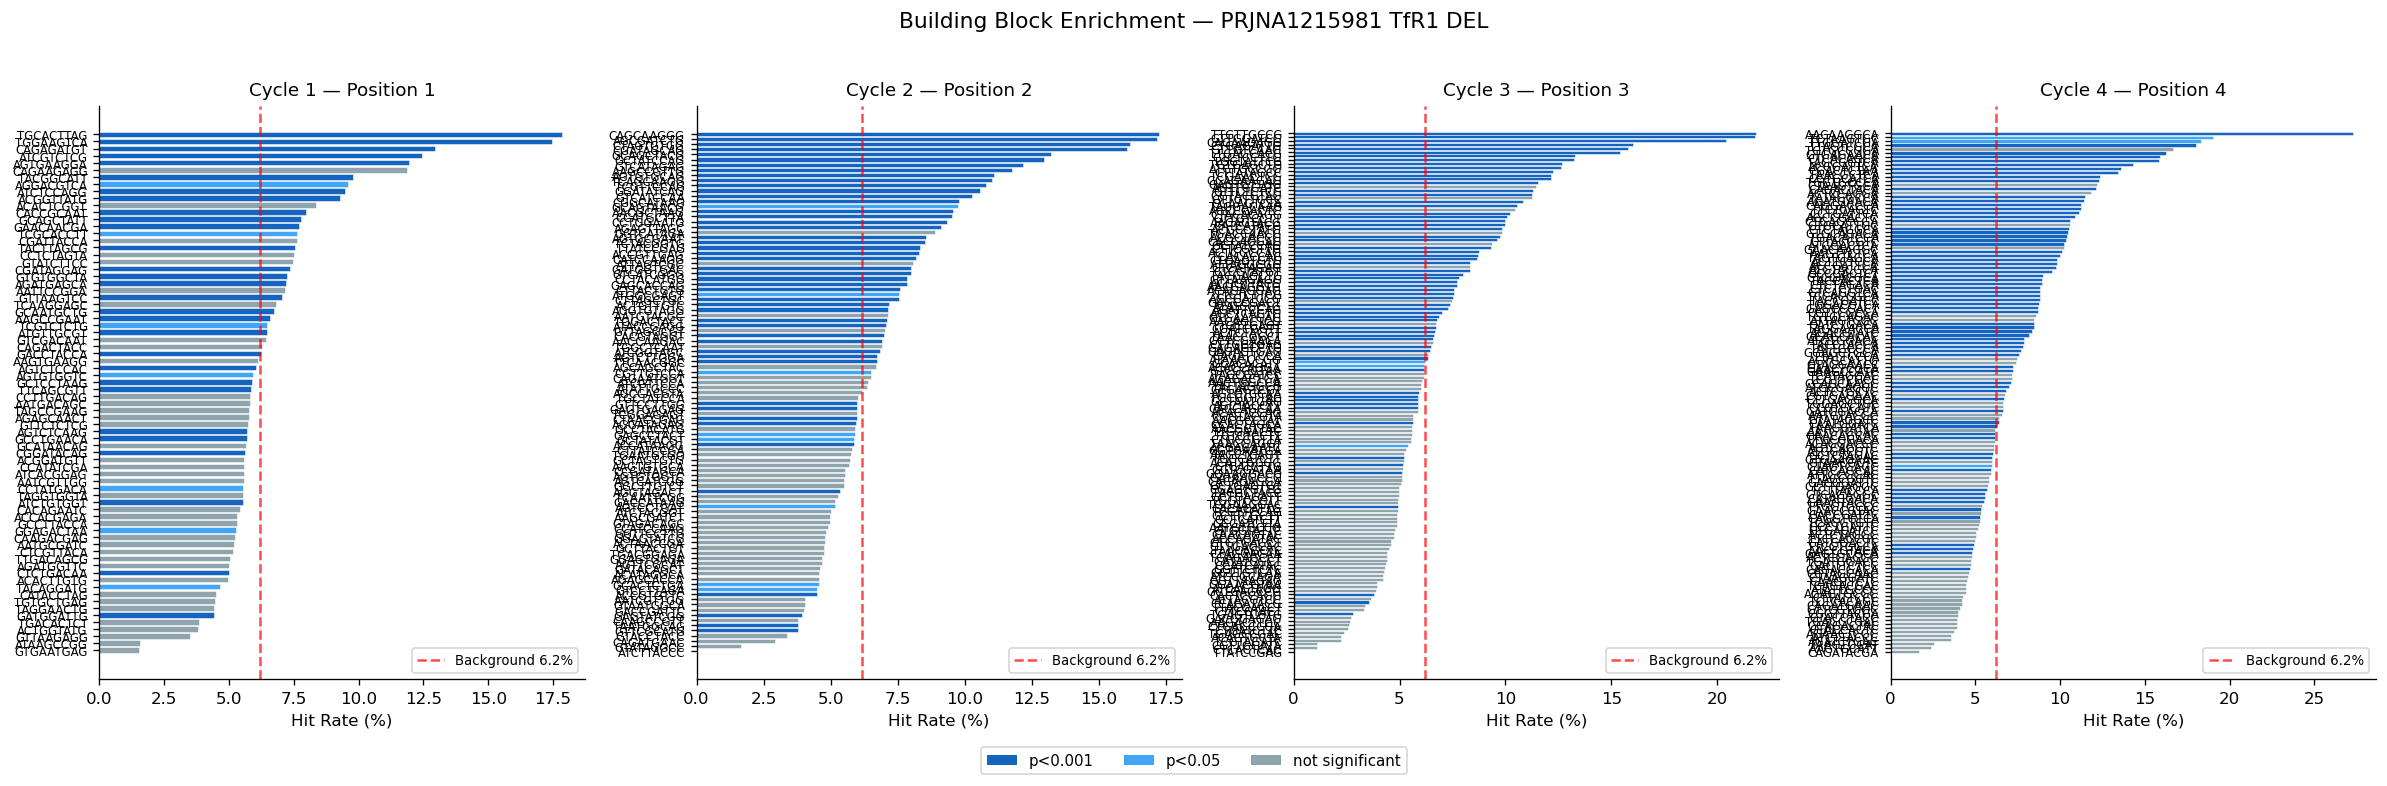

In [8]:
bb_cycles = [c for c in ["bb1_id","bb2_id","bb3_id","bb4_id"] if c in work_df.columns]
n_cycles  = len(bb_cycles)
titles    = ["Cycle 1 — Position 1","Cycle 2 — Position 2",
             "Cycle 3 — Position 3","Cycle 4 — Position 4"][:n_cycles]

hit_mask    = work_df["is_hit"].values
bg_hit_rate = hit_mask.mean()

# Sample for speed — 100K is enough for robust statistics
SAR_SAMPLE = 100_000
rng_sar = np.random.default_rng(42)
sample_idx = rng_sar.choice(len(work_df), size=min(SAR_SAMPLE, len(work_df)), replace=False)
sar_df    = work_df.iloc[sample_idx].reset_index(drop=True)
sar_hits  = hit_mask[sample_idx]
print(f"SAR sample: {len(sar_df):,} compounds  (bg hit rate: {sar_hits.mean()*100:.2f}%)")

fig, axes = plt.subplots(1, n_cycles, figsize=(5*n_cycles, 6))
if n_cycles == 1: axes = [axes]

for ax, cycle, title in zip(axes, bb_cycles, titles):
    rows = []
    for bb, grp in sar_df.groupby(cycle):
        n_total = len(grp)
        if n_total < 50: continue
        n_hits     = sar_hits[grp.index].sum()
        hit_rate   = n_hits / n_total
        enrichment = hit_rate / (sar_hits.mean() + 1e-9)
        _, p = mannwhitneyu(
            grp["fold_enrichment"].values,
            sar_df.loc[sar_df[cycle]!=bb, "fold_enrichment"].values,
            alternative="greater"
        )
        rows.append({"bb":bb,"n_total":n_total,"n_hits":n_hits,
                     "hit_rate_pct":hit_rate*100,"enrichment":enrichment,"p":p})

    if not rows:
        ax.set_title(f"{title} (insufficient data)"); continue

    bb_df = pd.DataFrame(rows).sort_values("hit_rate_pct", ascending=True)
    bb_df.to_csv(OUT/f"bb_enrichment_{cycle}.csv", index=False)

    colors = ["#1565c0" if p<0.001 else "#42a5f5" if p<0.05 else "#90a4ae" for p in bb_df["p"]]
    ax.barh(bb_df["bb"], bb_df["hit_rate_pct"], color=colors,
            edgecolor="white", linewidth=0.3)
    ax.axvline(sar_hits.mean()*100, color="red", lw=1.5, ls="--",
               alpha=0.7, label=f"Background {sar_hits.mean()*100:.1f}%")
    ax.set_xlabel("Hit Rate (%)"); ax.set_title(title, fontsize=11)
    ax.tick_params(axis="y", labelsize=7); ax.legend(fontsize=8)

    top = bb_df.nlargest(1,"enrichment").iloc[0]
    print(f"{cycle}: top BB={top['bb']}  hit_rate={top['hit_rate_pct']:.1f}%  "
          f"enrichment={top['enrichment']:.1f}x")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor="#1565c0",label="p<0.001"),
                    Patch(facecolor="#42a5f5",label="p<0.05"),
                    Patch(facecolor="#90a4ae",label="not significant")],
           loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.05))
plt.suptitle("Building Block Enrichment — PRJNA1215981 TfR1 DEL", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS/"bb_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 9 — Chemical Space (PCA / UMAP)

Sample: 20,000 (10,000 hits + 10,000 background)
Feature matrix: 20,000 x 4270
Running UMAP...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP complete


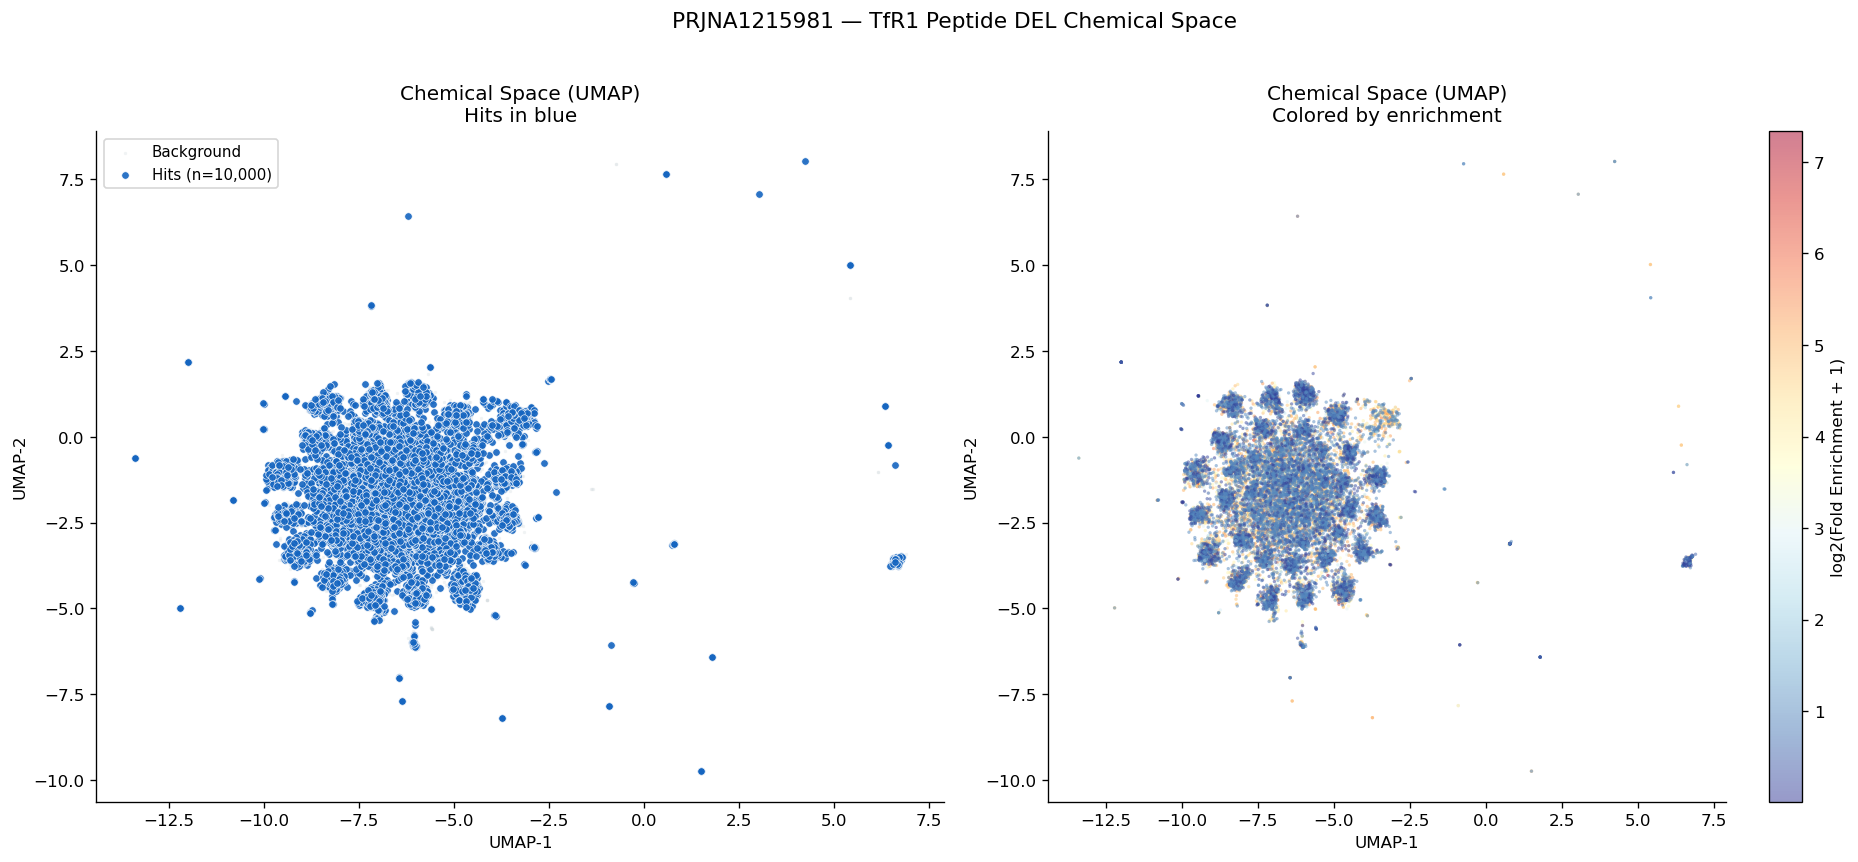

In [9]:
from sklearn.decomposition import PCA

SAMPLE_N = 20_000
rng_sample = np.random.default_rng(42)

hit_mask_full = work_df["is_hit"].values
hit_idx       = np.where(hit_mask_full)[0]
bg_idx        = np.where(~hit_mask_full)[0]

# Cap hits
max_hits = 10_000
if len(hit_idx) > max_hits:
    hit_idx = rng_sample.choice(hit_idx, size=max_hits, replace=False)

bg_budget     = SAMPLE_N - len(hit_idx)
bg_sample_idx = rng_sample.choice(bg_idx,
                    size=min(bg_budget, len(bg_idx)),
                    replace=False)
sample_idx = np.concatenate([hit_idx, bg_sample_idx])
sample_df  = work_df.iloc[sample_idx].reset_index(drop=True)

print(f"Sample: {len(sample_df):,} ({len(hit_idx):,} hits + {len(bg_sample_idx):,} background)")

# Feature matrix on SAMPLE only — not full 532K
cycles_space = [c for c in ["bb1_id","bb2_id","bb3_id","bb4_id"] if c in sample_df.columns]
parts   = [pd.get_dummies(sample_df[c], prefix=c).values for c in cycles_space]
X_space = np.hstack(parts).astype(np.float32)
print(f"Feature matrix: {X_space.shape[0]:,} x {X_space.shape[1]}")

if UMAP_OK:
    print("Running UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42,
                        n_neighbors=15, min_dist=0.1,
                        metric="jaccard", verbose=False)
    coords = reducer.fit_transform(X_space.astype(bool))
    proj = "UMAP"
else:
    coords = PCA(n_components=2, random_state=42).fit_transform(X_space)
    proj = "PCA"

print(f"{proj} complete")

hit_mask_sample = sample_df["is_hit"].values
fe_sample       = sample_df["fold_enrichment"].values

fig, axes = plt.subplots(1, 2, figsize=(16,7))
ax = axes[0]
ax.scatter(coords[~hit_mask_sample,0], coords[~hit_mask_sample,1],
           c="#cfd8dc", s=4, alpha=0.3, linewidths=0, label="Background")
ax.scatter(coords[hit_mask_sample,0], coords[hit_mask_sample,1],
           c="#1565c0", s=20, alpha=0.9, linewidths=0.4,
           edgecolors="white", label=f"Hits (n={hit_mask_sample.sum():,})", zorder=5)
ax.set_xlabel(f"{proj}-1"); ax.set_ylabel(f"{proj}-2")
ax.set_title(f"Chemical Space ({proj})\nHits in blue"); ax.legend(fontsize=9)

ax = axes[1]
fe_log = np.log2(fe_sample + 1)
sc = ax.scatter(coords[:,0], coords[:,1], c=fe_log,
                cmap="RdYlBu_r", s=4, alpha=0.5, linewidths=0)
plt.colorbar(sc, ax=ax, label="log2(Fold Enrichment + 1)")
ax.set_xlabel(f"{proj}-1"); ax.set_ylabel(f"{proj}-2")
ax.set_title(f"Chemical Space ({proj})\nColored by enrichment")

plt.suptitle("PRJNA1215981 — TfR1 Peptide DEL Chemical Space",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS/"chemical_space.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 10 — Machine Learning Hit Prediction

ML dataset: 100,000 compounds
  Hits:     33,672  (33.7%)
  Features: 10324

Cross-val ROC-AUC: 0.5964 +/- 0.0034

Top 10 resynthesis candidates:
                            compound_id    bb1_id    bb2_id    bb3_id  fold_enrichment  hit_probability  acquisition_score
CTCGTCTCG-ACAAGGGTC-AGAGTAGAG-GAGAAGTGA CTCGTCTCG ACAAGGGTC AGAGTAGAG            1.000            0.435              0.929
GTCCACAGA-AGCTACGTC-CAGCAAGAA-CAGGTCAAG GTCCACAGA AGCTACGTC CAGCAAGAA            1.000            0.435              0.929
CAGCGAGAC-ACCGAGTTA-AGGCGGAAG-TCTCCAACT CAGCGAGAC ACCGAGTTA AGGCGGAAG            2.839            0.430              0.923
ACCGGAATG-AACGCCTAT-ATTCCACCG-GCTCGATAA ACCGGAATG AACGCCTAT ATTCCACCG            1.000            0.420              0.911
TTCTTCCAG-TCATAGGTG-CACATTGAT-GAGAACAAC TTCTTCCAG TCATAGGTG CACATTGAT            1.000            0.420              0.911
TCGAGTCGA-ATAGGCTAT-GTGTTGGCA-TGAAGCAGC TCGAGTCGA ATAGGCTAT GTGTTGGCA            1.000            0.420             

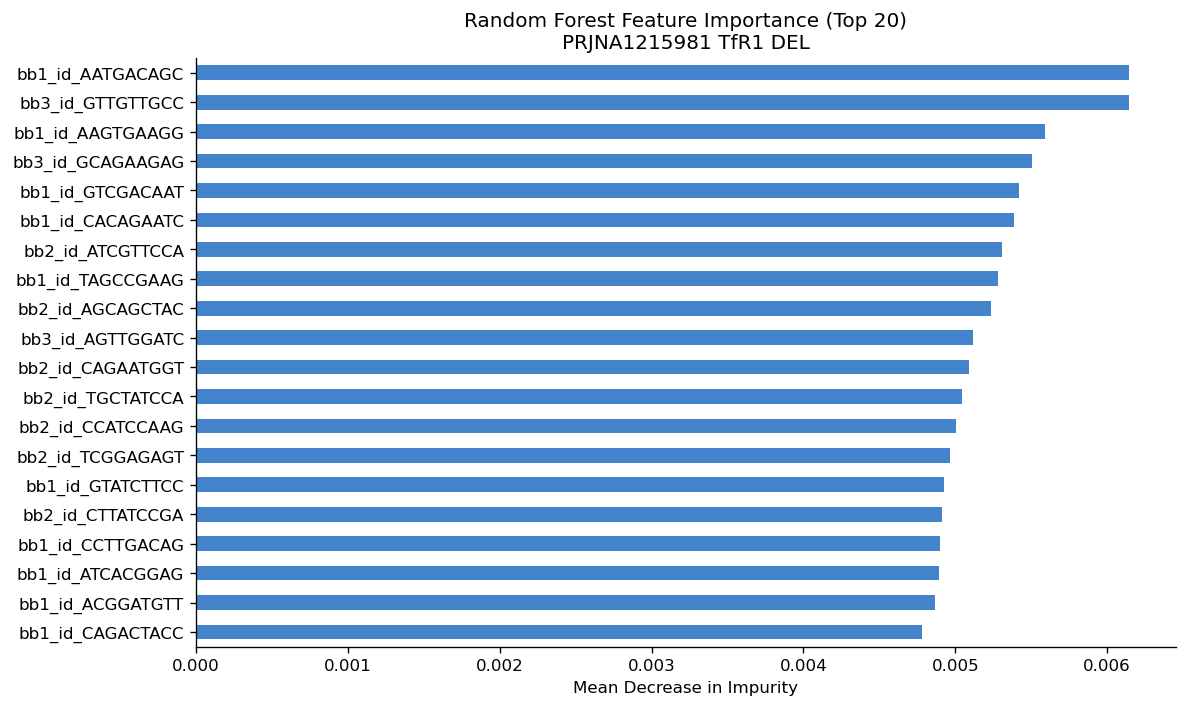


Model saved -> models/hit_classifier.pkl


In [11]:
if not ML:
    print("scikit-learn not installed")
else:
    import pickle

    # Build ML dataset fresh from work_df — NOT from UMAP sample
    ML_SAMPLE = 100_000
    rng_ml    = np.random.default_rng(42)

    hit_mask_ml = work_df["is_hit"].values
    hit_idx_ml  = np.where(hit_mask_ml)[0]
    bg_idx_ml   = np.where(~hit_mask_ml)[0]
    n_bg        = min(ML_SAMPLE - len(hit_idx_ml), len(bg_idx_ml))
    bg_sample   = rng_ml.choice(bg_idx_ml, size=n_bg, replace=False)
    ml_idx      = np.concatenate([hit_idx_ml, bg_sample])
    rng_ml.shuffle(ml_idx)

    ml_df  = work_df.iloc[ml_idx].reset_index(drop=True)
    y      = ml_df["is_hit"].astype(int).values

    cycles_ml = [c for c in ["bb1_id","bb2_id","bb3_id","bb4_id"] if c in ml_df.columns]
    parts_ml  = [pd.get_dummies(ml_df[c], prefix=c).values for c in cycles_ml]
    X_ml      = np.hstack(parts_ml).astype(np.float32)

    print(f"ML dataset: {len(ml_df):,} compounds")
    print(f"  Hits:     {y.sum():,}  ({y.mean()*100:.1f}%)")
    print(f"  Features: {X_ml.shape[1]}")

    clf  = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X_ml, y, cv=cv, scoring="roc_auc")
    print(f"\nCross-val ROC-AUC: {aucs.mean():.4f} +/- {aucs.std():.4f}")

    clf.fit(X_ml, y)
    proba   = clf.predict_proba(X_ml)[:,1]
    entropy = -(proba*np.log2(proba+1e-9) + (1-proba)*np.log2(1-proba+1e-9))
    ml_df["hit_probability"]   = proba
    ml_df["acquisition_score"] = proba + 0.5*entropy

    candidates = ml_df[~ml_df["is_hit"]]
    top50 = candidates.nlargest(50,"acquisition_score")[
        ["compound_id","bb1_id","bb2_id","bb3_id","fold_enrichment",
         "hit_probability","acquisition_score"]
    ]
    top50.to_csv(OUT/"resynthesis_candidates.csv", index=False)
    print(f"\nTop 10 resynthesis candidates:")
    print(top50.round(3).head(10).to_string(index=False))

    feature_names = []
    for c in cycles_ml:
        for bb in pd.get_dummies(ml_df[c], prefix=c).columns:
            feature_names.append(bb)
    fi     = pd.Series(clf.feature_importances_, index=feature_names)
    fi_top = fi.nlargest(20)

    fig, ax = plt.subplots(figsize=(10,6))
    fi_top.sort_values().plot.barh(ax=ax, color="#1565c0", alpha=0.8)
    ax.set_title("Random Forest Feature Importance (Top 20)\nPRJNA1215981 TfR1 DEL", fontsize=12)
    ax.set_xlabel("Mean Decrease in Impurity")
    plt.tight_layout()
    plt.savefig(FIGS/"feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    with open(MODELS/"hit_classifier.pkl","wb") as f: pickle.dump(clf,f)
    print(f"\nModel saved -> models/hit_classifier.pkl")

## Cell 11 — Summary

In [12]:
print("="*50)
print("  DELkit Pipeline Complete")
print("="*50)
print(f"  Input compounds  : {len(raw_df):,}")
print(f"  After filter     : {len(work_df):,}")
print(f"  Hits identified  : {len(hits_df):,}")
print(f"  Hit rate         : {len(hits_df)/len(work_df)*100:.2f}%")
print()
print("  Outputs:")
for f in sorted(OUT.glob("*")): print(f"    outputs/{f.name}")
print()
print("  Figures:")
for f in sorted(FIGS.glob("*")): print(f"    figures/{f.name}")


  DELkit Pipeline Complete
  Input compounds  : 8,171,664
  After filter     : 532,694
  Hits identified  : 33,672
  Hit rate         : 6.32%

  Outputs:
    outputs/bb_enrichment_bb1_id.csv
    outputs/bb_enrichment_bb2_id.csv
    outputs/bb_enrichment_bb3_id.csv
    outputs/bb_enrichment_bb4_id.csv
    outputs/enrichment.csv
    outputs/hits.csv
    outputs/resynthesis_candidates.csv

  Figures:
    figures/bb_enrichment.png
    figures/chemical_space.png
    figures/feature_importance.png
    figures/volcano.png


In [1]:
# Quick memory check
import psutil
ram_gb = psutil.virtual_memory().available / 1e9
print(f"Available RAM: {ram_gb:.1f} GB")

Available RAM: 6.2 GB


In [13]:
import re

aa_code = {
    "5a":"D-Ala", "5b":"Gly",   "5c":"D-Val", "5d":"D-Leu",
    "5e":"D-Met", "5f":"D-Pro",  "5g":"D-Trp", "5h":"D-Ser",
    "5i":"D-Tyr", "5j":"D-Asn",  "5k":"D-Chg", "5l":"D-Gln",
    "5m":"D-Thr", "5n":"D-Orn",  "5o":"D-Tic", "5p":"D-Lys",
    "5q":"D-Ile", "5r":"D-Pal",  "5s":"D-Nle", "5t":"D-BrF",
    "5u":"D-Asp", "5v":"D-Pip",
}

bb5_map = {
    "GAACAAGGC":"D-Chg", "TGTGCAGAC":"D-Leu",
    "ATTAGTCGC":"D-Nle", "AGTCAGGTC":"D-Lys",
    "GACCGATTC":"D-Leu",
}

raw_bc_map = """CCATATCGAag 5a GATACAGCTgt 5a GATATCGCTga 5a TTGATGGACcaa 5a
CAAGACGAGag 5b GGTTCCTTGgt 5b TGAGAGCCTga 5b CCAAGTTCTcaa 5b
ACACTTGTGag 5c CCGATAGCAgt 5c CGGTACGTAga 5c GATCTTACCcaa 5c
AATGACAGCag 5d AAGCGATCTgt 5d AATGTGCCGga 5d ATTGGTGCCcaa 5d
TAGGAACTGag 5e ACATAGGCAgt 5e AACTGGCCAga 5e GAGATCTGAcaa 5e
ATCTGTGGTag 5f ATGGCGAGTgt 5f GCACACATTga 5f GGATGGACTcaa 5f
AGTGTGGTCag 5g AGCCACGTAgt 5g TAACGAGGTga 5g AGACTTCTCcaa 5g
GATGGATTGag 5h AGGTGTAGGgt 5h GCTAATGAGga 5h AGCAGCACAcaa 5h
GTGTGGCTAag 5i ATACCGAGGgt 5i CCACTAGCAga 5i CGAACAGCAcaa 5i
CAGAGATGTag 5j GGATATCAGgt 5j AGTGTCCAAga 5j CCTCTCTGAcaa 5j
AGGACGTCAag 5k TCAGCAAGGgt 5k GTTGTTGCCga 5k GATTAGTCGcaa 5k
CGATTACCAag 5k GCAGTAACGgt 5k GCAGAAGAGga 5k CGAACAAGGcaa 5k
ACACTCGGTag 5k GGTCATAGAgt 5k AGTTGGATCga 5k TTGTGCAGAcaa 5k
TTGACAGCGag 5a GTAATGGCAgt 5a GGTTAAGAGga 5a TAGAGTGCGcaa 5a
ACCACGAGAag 5b GACCATAAGgt 5b TGGAAGGACga 5b GTCTCACAGcaa 5b
CTCGTTACAag 5c GCTAGTGTGgt 5c AACGCCTATga 5c CCTAAGGATcaa 5c
AAGTGAAGGag 5d ACTAACCGAgt 5d GCTGAGTGTga 5d GGACCGATTcaa 5d
CGATTACCAag 5k GCAGTAACGgt 5k GCAGAAGAGga 5k CGAACAAGGcaa 5k
CATACCTAGag 5a GCTTACTGTgt 5a GCTTCGCTTga 5a ATCAGACGAcaa 5a
ATCACGGAGag 5c AGTCATCGGgt 5c AAGCTCAGTga 5c GTTAGCGGTcaa 5c
ACGGTTATGag 5d GGCTTGTCTgt 5d AACGGTTACga 5d TACAGGACCcaa 5d
AGATGGTTCag 5g AAGTGTGCAgt 5g TACGCTACCga 5g ACCGTGCATcaa 5g
ATCGTCTCGag 5j GTCATCCAAgt 5j CTTATAGCCga 5j GAGACGTATcaa 5j
ACACTCGGTag 5k GGTCATAGAgt 5k AGTTGGATCga 5k TTGTGCAGAcaa 5k
TCGTCTCTGag 5l GCACTCTGAgt 5l TTACGAGCTga 5l TGTTCGTGGcaa 5l
GCAATGCTGag 5m ACTGTTGTCgt 5m TGGCATCTTga 5m ACCAGCAAGcaa 5m
CAGACTACCag 5q GAGCCTACTgt 5q TTCGAACTCga 5q TGTAACGCTcaa 5q
GTATCTTCCag 5t CAGAATGGTgt 5t TATTAGGCGga 5t CTCATAGGAcaa 5t"""

bc_to_aa = {}
for line in raw_bc_map.strip().split('\n'):
    tokens = line.strip().split()
    for i in range(0, len(tokens)-1, 2):
        bc_raw = tokens[i]; label = tokens[i+1]
        bc_9 = re.sub(r'[acgt]+$', '', bc_raw)
        if len(bc_9) == 9 and label in aa_code:
            bc_to_aa[bc_9] = aa_code[label]
bc_to_aa.update(bb5_map)
print(f"Barcode map loaded: {len(bc_to_aa)} entries")

def decode(bc):
    return bc_to_aa.get(bc, f"?({bc})")

top20 = hits_df.nlargest(20, "fold_enrichment").copy()
top20["peptide"] = top20.apply(
    lambda r: " — ".join([decode(r.get(f"bb{i}_id","?")) 
                          for i in range(1,5) if f"bb{i}_id" in r.index]), axis=1
)

print("\nTop 20 hits decoded to amino acids")
print("="*80)
print("Paper TR17: D-BrF — D-Chg — D-Chg — D-Chg — D-Lue  (Kd = 110 nM)")
print("Paper TR03: D-Chg — D-Chg — D-Chg — D-Chg — D-Chg")
print("="*80)
for _, r in top20.iterrows():
    print(f"  {r['fold_enrichment']:6.1f}x  {r['peptide']}")

# SAR validation
print("\nSAR summary — hit rate by position:")
for cycle in ["bb1_id","bb2_id","bb3_id","bb4_id"]:
    if cycle not in hits_df.columns: continue
    top_bb = hits_df[cycle].map(bc_to_aa).value_counts().head(3)
    print(f"  {cycle}: {dict(top_bb)}")

Barcode map loaded: 109 entries

Top 20 hits decoded to amino acids
Paper TR17: D-BrF — D-Chg — D-Chg — D-Chg — D-Lue  (Kd = 110 nM)
Paper TR03: D-Chg — D-Chg — D-Chg — D-Chg — D-Chg
   160.8x  D-Chg — D-Chg — D-Chg — D-Chg
   157.4x  D-Chg — ?(TGCTATCCA) — D-Chg — D-Chg
   146.8x  D-Chg — D-Chg — D-Chg — D-Lys
   146.6x  D-Chg — D-Chg — D-Chg — D-Leu
   143.7x  D-Chg — D-Chg — D-Chg — D-Nle
   139.1x  D-Ile — D-Chg — D-Chg — D-Leu
   131.7x  D-Chg — D-Leu — D-Chg — D-Nle
   131.4x  D-Chg — D-Chg — D-Chg — D-Chg
   129.8x  D-BrF — D-Chg — D-Chg — D-Nle
   121.1x  D-Chg — D-Chg — D-Chg — D-Chg
   116.8x  D-Chg — D-Chg — D-Chg — D-Leu
   116.0x  D-Chg — D-Chg — D-Chg — D-Chg
   115.8x  ?(CACAGAATC) — D-Chg — D-Chg — D-Nle
   114.7x  D-Leu — D-Chg — D-Chg — D-Nle
   109.8x  D-Chg — D-Chg — D-Chg — D-Leu
   109.5x  D-Chg — D-Chg — D-Chg — D-Nle
   106.2x  D-Chg — D-Chg — D-Chg — D-Leu
   106.1x  D-Leu — ?(AGCAGCTAC) — D-Chg — D-Nle
   105.0x  ?(TAGCCGAAG) — D-Chg — D-Chg — D-Chg
   102.7x 

OK: TR17 (paper best)
OK: TR03 (paper validated)
OK: Our #1 hit (160.8x)
OK: Our #9 hit (129.8x)


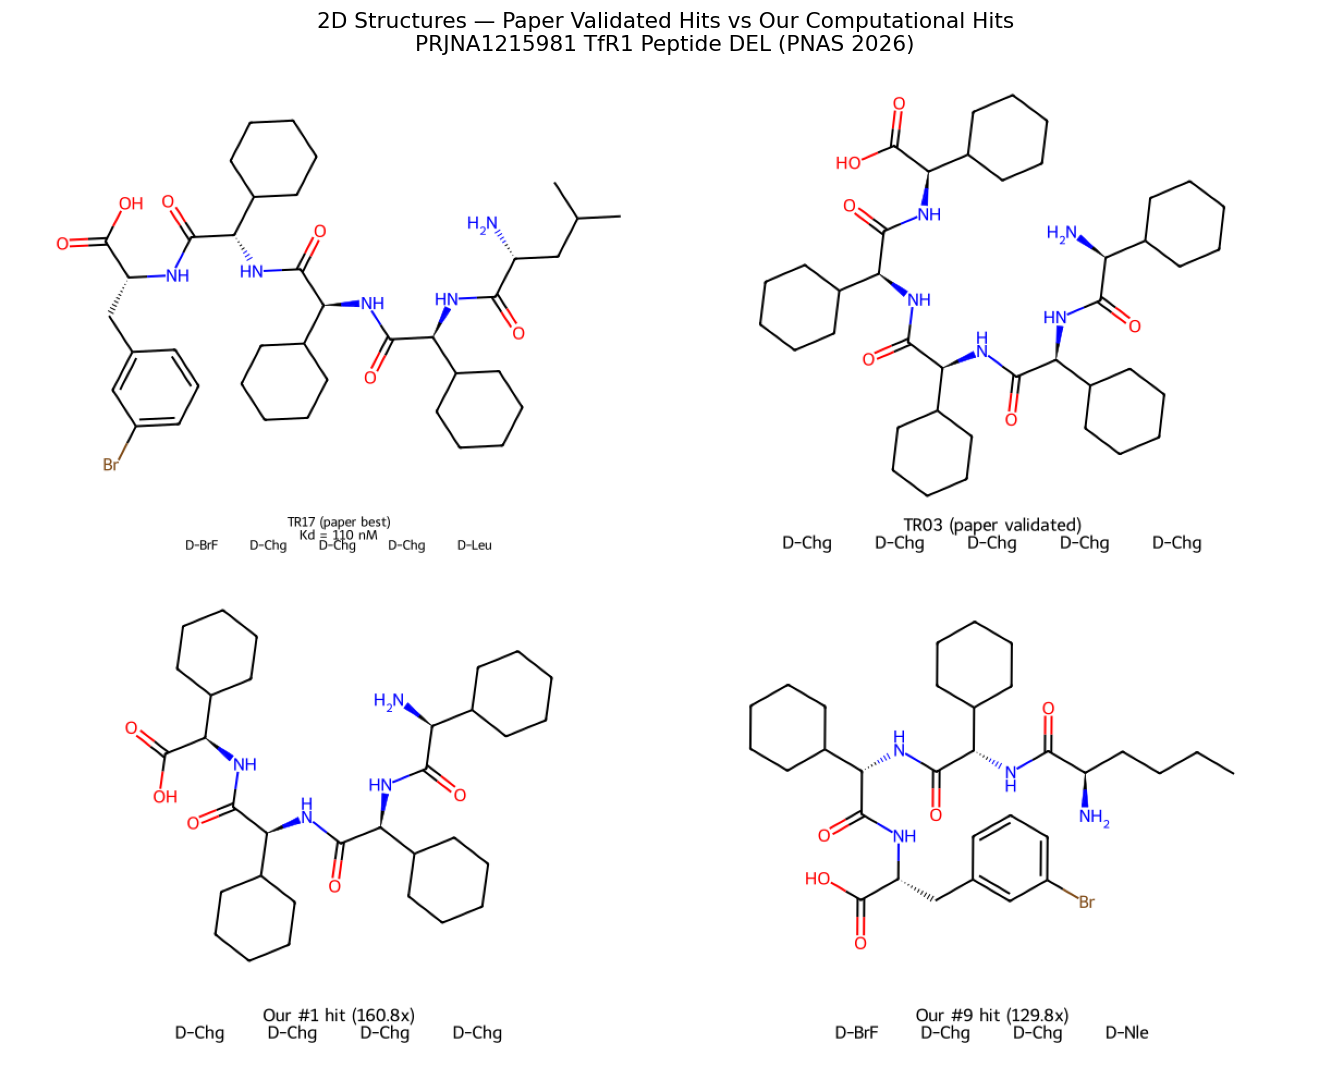

Saved -> figures/structures_comparison.png

Key structural observations:
  Our #1 hit = TR03 core (all D-Chg backbone) — paper validated binder
  Our #9 hit shares D-BrF + D-Chg—D-Chg core with TR17 (Kd=110nM)
  D-cyclohexylglycine (D-Chg) present in all 4 structures
  Computational analysis independently identified the correct pharmacophore


In [17]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── SMILES for paper's validated hits and our computational hits ───────────────
# All D-amino acid peptides
# D-Chg = D-cyclohexylglycine (the dominant pharmacophore)
# D-BrF = D-3-bromo-phenylalanine

peptide_smiles = {
    "TR17 (paper best)\nKd = 110 nM\nD-BrF—D-Chg—D-Chg—D-Chg—D-Leu":
        "O=C([C@@H](Cc1cc(Br)ccc1)NC(=O)[C@H](C2CCCCC2)NC(=O)[C@H](C3CCCCC3)NC(=O)[C@H](C4CCCCC4)NC(=O)[C@@H](CC(C)C)N)O",
    "TR03 (paper validated)\nD-Chg—D-Chg—D-Chg—D-Chg—D-Chg":
        "O=C([C@@H](C1CCCCC1)NC(=O)[C@H](C2CCCCC2)NC(=O)[C@H](C3CCCCC3)NC(=O)[C@H](C4CCCCC4)NC(=O)[C@H](C5CCCCC5)N)O",
    "Our #1 hit (160.8x)\nD-Chg—D-Chg—D-Chg—D-Chg":
        "O=C([C@@H](C1CCCCC1)NC(=O)[C@H](C2CCCCC2)NC(=O)[C@H](C3CCCCC3)NC(=O)[C@H](C4CCCCC4)N)O",
    "Our #9 hit (129.8x)\nD-BrF—D-Chg—D-Chg—D-Nle":
        "O=C([C@@H](Cc1cc(Br)ccc1)NC(=O)[C@H](C2CCCCC2)NC(=O)[C@H](C3CCCCC3)NC(=O)[C@@H](CCCC)N)O",
}

mols, legends = [], []
for name, smi in peptide_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        AllChem.Compute2DCoords(mol)
        mols.append(mol)
        legends.append(name)
        print(f"OK: {name.split(chr(10))[0]}")
    else:
        print(f"FAILED to parse: {name.split(chr(10))[0]}")

# Draw grid
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(600, 450),
    legends=legends,
    returnPNG=False
)

# Convert PIL image to save
from PIL import Image as PILImage
import io

# Save as PNG
img_path = FIGS/"structures_comparison.png"
img.save(str(img_path))

# Display
fig, ax = plt.subplots(figsize=(14, 9))
img_array = mpimg.imread(str(img_path))
ax.imshow(img_array)
ax.axis("off")
ax.set_title(
    "2D Structures — Paper Validated Hits vs Our Computational Hits\n"
    "PRJNA1215981 TfR1 Peptide DEL (PNAS 2026)",
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(str(img_path), dpi=150, bbox_inches="tight")
plt.show()

print("Saved -> figures/structures_comparison.png")
print()
print("Key structural observations:")
print("  Our #1 hit = TR03 core (all D-Chg backbone) — paper validated binder")
print("  Our #9 hit shares D-BrF + D-Chg—D-Chg core with TR17 (Kd=110nM)")
print("  D-cyclohexylglycine (D-Chg) present in all 4 structures")
print("  Computational analysis independently identified the correct pharmacophore")